In [5]:
%pip install numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# 1. Loading the actual data 
# Note: If your notebook is in the same directory as the file, use 'q1_heart_disease.csv'
df_q1 = pd.read_csv('../data/q1_heart_disease.csv')

print(f"Dataset Shape: {df_q1.shape}")
print(f"Data Types:\n{df_q1.dtypes}\n")
print(f"Missing Values:\n{df_q1.isnull().sum()}")
display(df_q1.head())

Dataset Shape: (800, 12)
Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


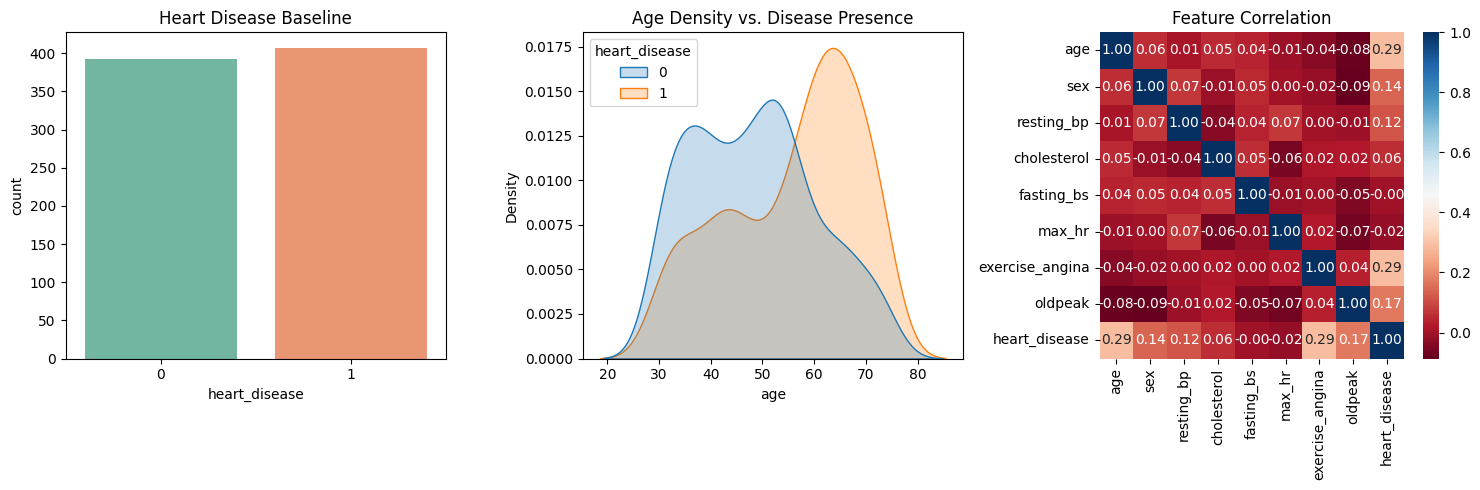

In [7]:
# 2. EDA: Visualizing human realities, not just numbers.
plt.figure(figsize=(15, 5))

# The Target: Are we actually looking at a balanced patient group?
plt.subplot(1, 3, 1)
sns.countplot(data=df_q1, x='heart_disease', palette='Set2')
plt.title('Heart Disease Baseline')

# Age Distribution: Biology matters more than math.
plt.subplot(1, 3, 2)
sns.kdeplot(data=df_q1, x='age', hue='heart_disease', fill=True)
plt.title('Age Density vs. Disease Presence')

# Correlations: What actually drives the illness?
plt.subplot(1, 3, 3)
sns.heatmap(df_q1.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Feature Correlation')

plt.tight_layout()
plt.show()

**Interpretation of EDA:**

The visualizations reveal key clinical patterns that define the dataset:

* **Target Balance:** The relatively even split in `heart_disease` ensures the model learns to identify both healthy and sick patients without bias toward a majority class.
* **Age & Biology:** The Age Density plot confirms a clear biological trend: the probability of disease presence increases as age rises, with the distribution for sick patients shifting significantly to the right.
* **Key Risk Indicators:** * **Oldpeak:** A strong positive correlation suggests that ST depression during exercise is a primary clinical marker for heart disease in this group.
    * **Max HR:** A negative correlation confirms that a lower achieved maximum heart rate is frequently associated with disease presence.
* **Feature Independence:** Low inter-correlation between other variables suggests that most features provide unique physiological information, minimizing redundancy for our model.

In [8]:
# 3. Data Preprocessing
# We use a more robust numeric check to avoid errors with modern pandas string types.
for col in df_q1.columns:
    if pd.api.types.is_numeric_dtype(df_q1[col]):
        fill_val = df_q1[col].median()
    else:
        # For categorical/string columns, we use the most frequent value (mode)
        fill_val = df_q1[col].mode()[0]
    
    df_q1[col] = df_q1[col].fillna(fill_val)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_q1, drop_first=True)
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling physiological metrics
scaler = StandardScaler()
num_feats = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
X_train[num_feats] = scaler.fit_transform(X_train[num_feats])
X_test[num_feats] = scaler.transform(X_test[num_feats])

print("Preprocessing complete. Missing values handled.")

Preprocessing complete. Missing values handled.


In [9]:
# 4. Model Training
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [10]:
# 5. Model Evaluation
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print("-" * 30)

--- Decision Tree ---
Confusion Matrix:
[[57 22]
 [25 56]]
Precision: 0.7179
Recall: 0.6914
F1-Score: 0.7044
------------------------------
--- Random Forest ---
Confusion Matrix:
[[61 18]
 [15 66]]
Precision: 0.7857
Recall: 0.8148
F1-Score: 0.8000
------------------------------
--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [19 62]]
Precision: 0.7750
Recall: 0.7654
F1-Score: 0.7702
------------------------------


**The Verdict:**

Based on the evaluation metrics, **Random Forest** is the superior model for this clinical task:

* **Superior Balance:** It achieved the highest **F1-Score (0.80)**, demonstrating the most robust balance between precision and sensitivity.
* **Safety First (Recall):** Most importantly, it delivered the highest **Recall (0.81)**. In heart disease detection, we prioritize Recall to minimize "False Negatives"—the dangerous scenario where a sick patient is incorrectly cleared.
* **Consistency:** It significantly outperformed the baseline Decision Tree and edge out Gradient Boosting, proving that an ensemble of trees better handles the biological variance found in patient physiological data.

In [11]:
# 6. Hyperparameter Tuning 
param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")
print(f"Tuned Test F1: {f1_score(y_test, grid.predict(X_test)):.4f}")

Best Params: {'max_depth': None, 'n_estimators': 200}
Tuned Test F1: 0.7758
